# Imports y cargar dataframe

In [73]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [74]:
import pandas as pd

df = pd.read_csv('data.csv')

/var/folders/xw/knfpkcxn1_x07xvqxkkgpc1r0000gn/T/ipykernel_10631/546824446.py:3: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data.csv')


# Limpieza de datos

In [75]:
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42305 entries, 0 to 42304
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   danceability      42305 non-null  float64
 1   energy            42305 non-null  float64
 2   key               42305 non-null  int64  
 3   loudness          42305 non-null  float64
 4   mode              42305 non-null  int64  
 5   speechiness       42305 non-null  float64
 6   acousticness      42305 non-null  float64
 7   instrumentalness  42305 non-null  float64
 8   liveness          42305 non-null  float64
 9   valence           42305 non-null  float64
 10  tempo             42305 non-null  float64
 11  type              42305 non-null  object 
 12  id                42305 non-null  object 
 13  uri               42305 non-null  object 
 14  track_href        42305 non-null  object 
 15  analysis_url      42305 non-null  object 
 16  duration_ms       42305 non-null  int64 

## Quitar nulos

Para poder aplicar PCA, TSNE y UMAP correctamente, utilizamos solamente las variables númericas. Además, se ha optado por eliminar los valores nulos para simplificar el ejercicio.

In [76]:
df_numeric = df.select_dtypes(include=['float64'])

df_numeric = df_numeric.dropna()

display(df_numeric.isna().sum())

danceability        0
energy              0
loudness            0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
Unnamed: 0          0
dtype: int64

## Escalado de los datos

In [77]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

# Reducción de la dimensionalidad

Se van a utilizar diferentes modelos PCA, TSNE y UMAP para reducir la dimensionalidad a 2 dimensiones (2 características) y comprobar sus resultados.

## PCA

Realizamos primero un PCA para ver su comportamiento

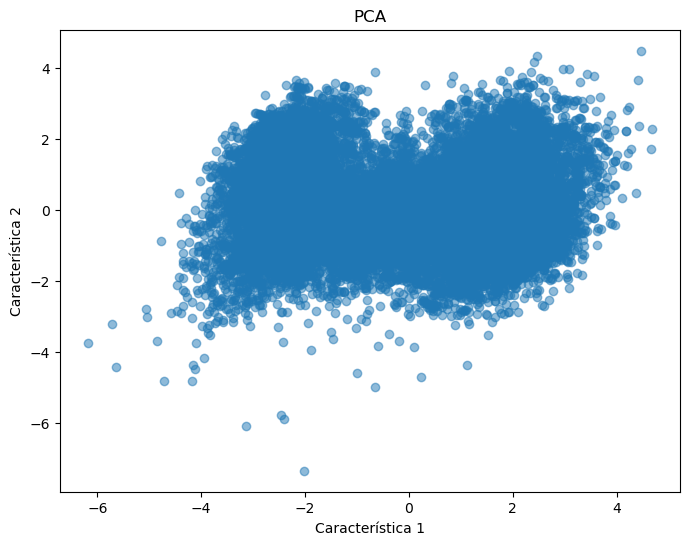

In [78]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.5)
plt.title('PCA')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.show()

Se observa que no hay clusters claros a simple vista, aunque podría haber dos grandes grupos (se analizará más adelante con más detalle).

## TSNE
Se realiza ahora un TSNE a ver si utilizando este modelo conseguimos ver grupos más diferenciados

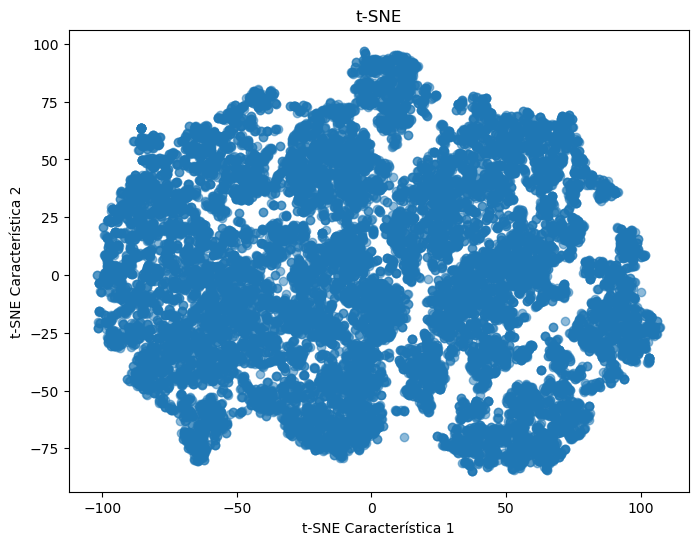

In [79]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsme = TSNE(n_components=2, random_state=42)
tmsne_result = tsme.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(tmsne_result[:,0], tmsne_result[:,1], alpha=0.5)
plt.title('t-SNE')
plt.xlabel('t-SNE Característica 1')
plt.ylabel('t-SNE Característica 2')
plt.show()

Se observa que con TSNE tampoco mejora mucho la clusterización a simple vista. Posteriormente lo evaluaremos con más detalle.

## UMAP
Ahora probamos con el modelo U-MAP y evaluamos los resultados.

/opt/homebrew/anaconda3/envs/ml311/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


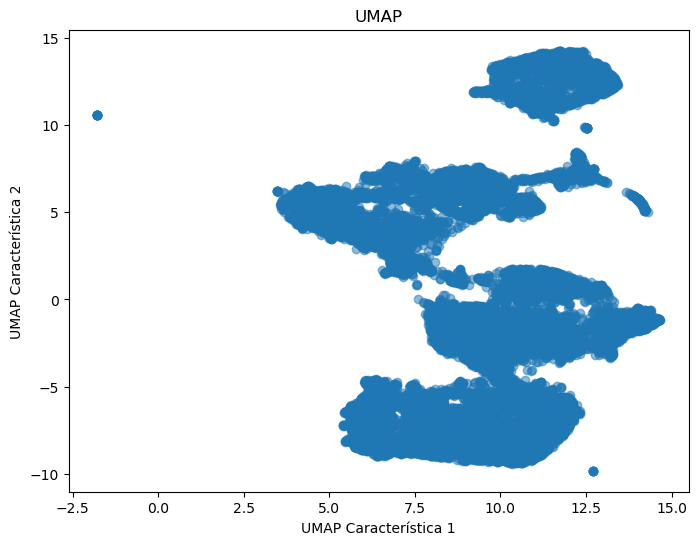

In [80]:
import umap
import matplotlib.pyplot as plt
import pandas as pd

umap_reducer = umap.UMAP(n_components=2, random_state=42)
umap_result = umap_reducer.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(umap_result[:,0], umap_result[:,1], alpha=0.5)
plt.title('UMAP')
plt.xlabel('UMAP Característica 1')
plt.ylabel('UMAP Característica 2')
plt.show()

Observamos que aquí sí que parece haber 4 grandes grupos.

# Clustering

Una vez hemos probado los diferentes modelos, vamos a evaluar más en detalle como se comportan cada uno de ellos y a realizar un clustering en cada caso en base a esos resultados.

## Clustering PCA
Para realizar el clustering correctamente, es necesario evaluar el número óptimo de clusters. Para eso utilizaremos varios métodos como el del codo y la evaluación del silohouette medio para diferentes valores de k (numero de clusters).

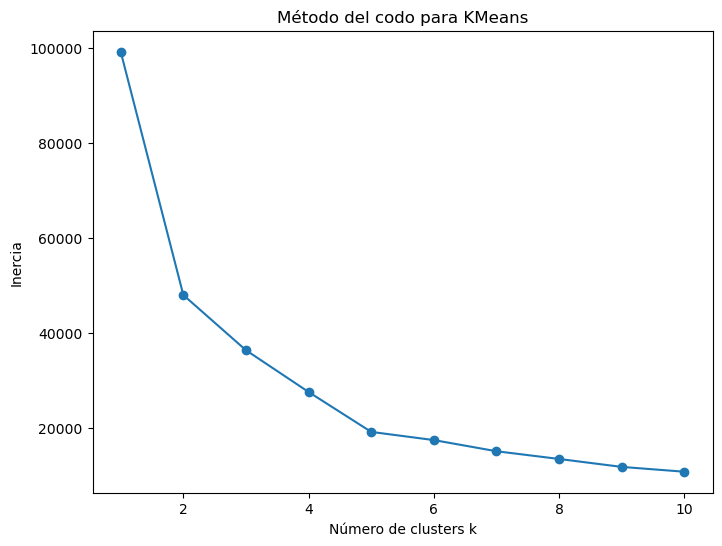

In [81]:
from sklearn.cluster import KMeans

# Método del codo para KMeans
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(8,6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Método del codo para KMeans')
plt.xlabel('Número de clusters k')
plt.ylabel('Inercia')
plt.show()

Por ahora, parece que el k óptimo es k=5

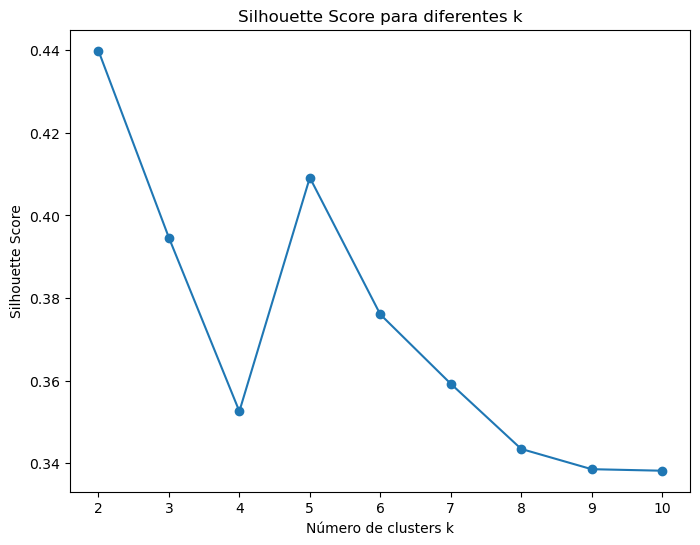

In [82]:
from sklearn.metrics import silhouette_score

# Metodo del codo para encontrar el número óptimo de clusters.
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    silhouette_scores.append(score)
plt.figure(figsize=(8,6))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Score para diferentes k')
plt.xlabel('Número de clusters k')
plt.ylabel('Silhouette Score')
plt.show()


Tras plotear el silhouette score, parece que k=5 es una buena elección.

Realizamos el clustering final con k=4 y observamos el resultado.

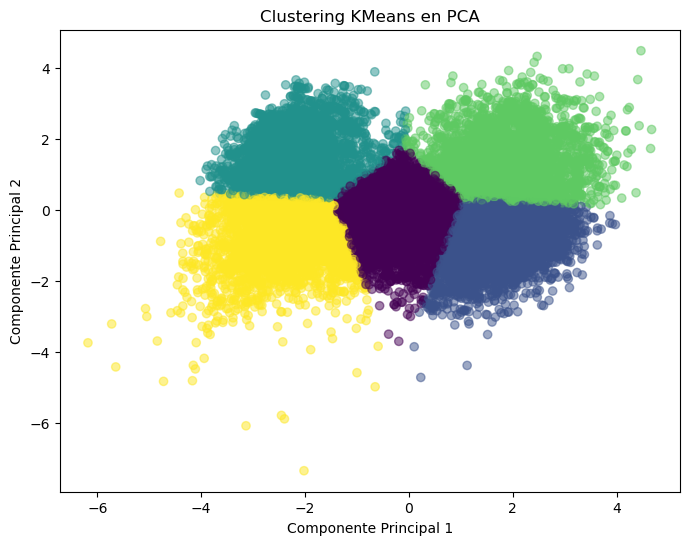

In [83]:
from sklearn.cluster import KMeans

#Plotear el resultado de KMeans en PCA.
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_pca)
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis', alpha=0.5)
plt.title('Clustering KMeans en PCA')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

Aunque intuitivamente podía parecer que el número óptimo de clusters era 2, parece que 5 es una mejor opción. No obstante, el valor de silhouette no es muy bueno y no hay grupos muy diferenciados.

## Clustering K-MEANS
Realizamos el mismo proceso que anteriormente pero ahora utilizando el modelo de TSNE, para ver si obtenemos mejores resultados.

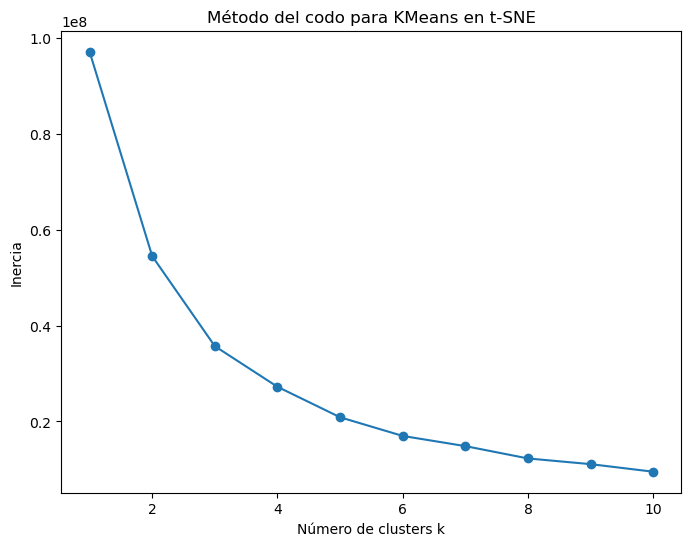

In [84]:
# Método del codo para KMeans en t-SNE
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(tmsne_result)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(8,6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Método del codo para KMeans en t-SNE')
plt.xlabel('Número de clusters k')
plt.ylabel('Inercia')
plt.show()


En este caso, no se ve tan clara cual es la k óptima. Se intuye que k puede estar entre el 4 y el 5

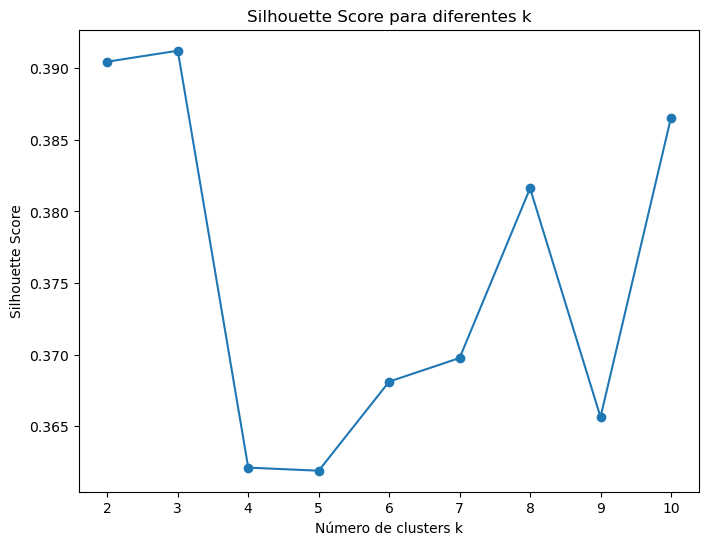

In [85]:
from sklearn.metrics import silhouette_score
# Silhouette score para evaluar el clustering en t-SNE
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(tmsne_result)
    score = silhouette_score(tmsne_result, labels)
    silhouette_scores.append(score)
plt.figure(figsize=(8,6))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Score para diferentes k')
plt.xlabel('Número de clusters k')
plt.ylabel('Silhouette Score')
plt.show()


En este caso vemos que el eje vertical varía muy poco, los valores no son demasiado concluyentes. Esto encaja en la teoría de que no se ven grupos diferenciados. Se elije k = 3 ya que es el mayor valor de silhouette, aunque este es pequeño.

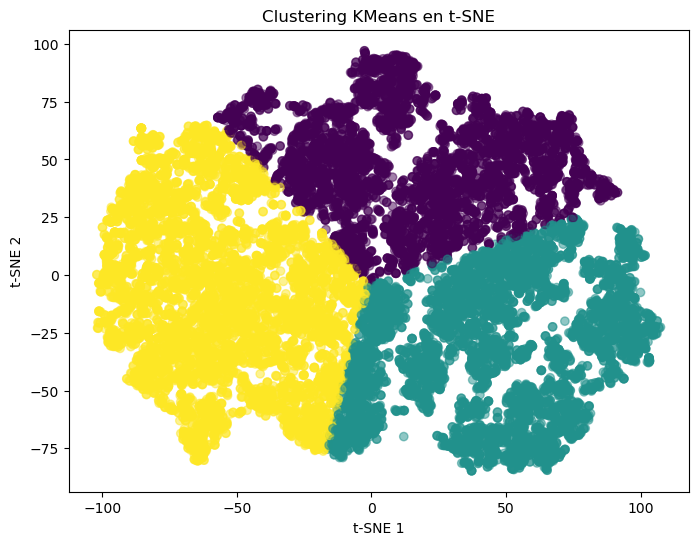

In [86]:
# Plotear el resultado de KMeans en t-SNE.
kmeans_tsne = KMeans(n_clusters=3, random_state=42)
clusters_tsne = kmeans_tsne.fit_predict(tmsne_result)
plt.figure(figsize=(8,6))
plt.scatter(tmsne_result[:,0], tmsne_result[:,1], c=clusters_tsne, cmap='viridis', alpha=0.5)
plt.title('Clustering KMeans en t-SNE')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()

Como se esperaba, la clusterización en ese caso deja bastante que desear.

## Clustering U-MAP
Realizamos el mismo proceso que anteriormente pero ahora utilizando el modelo de UMAP, para ver si obtenemos mejores resultados.

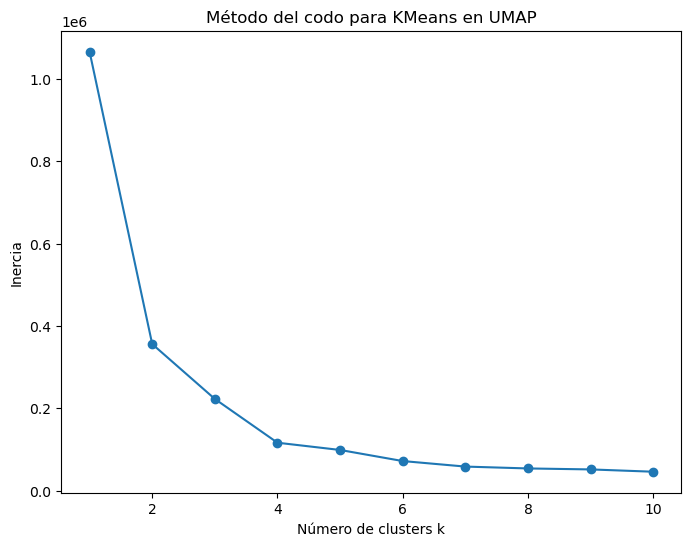

In [87]:
# Método del codo para encontrar el número óptimo de clusters
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(umap_result)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(8,6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Método del codo para KMeans en UMAP')
plt.xlabel('Número de clusters k')
plt.ylabel('Inercia')
plt.show()

En este caso parece que el número adecuado es k=4 

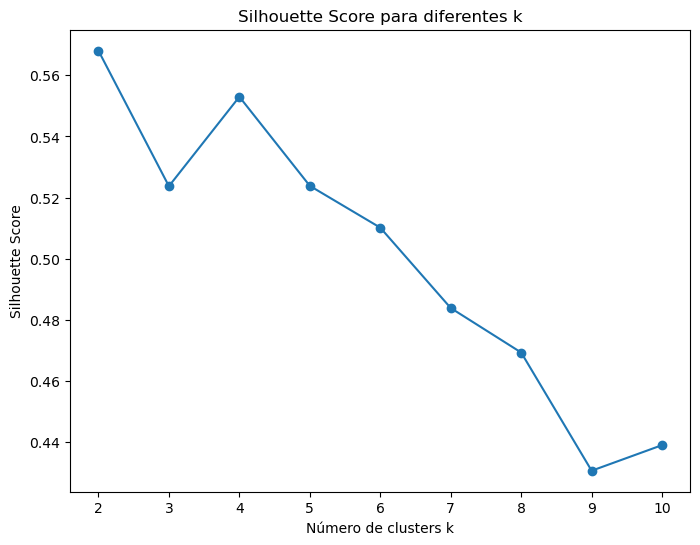

In [88]:
from sklearn.metrics import silhouette_score

# Silhouette score para evaluar el clustering en UMAP
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(umap_result)
    score = silhouette_score(umap_result, labels)
    silhouette_scores.append(score)
plt.figure(figsize=(8,6))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Score para diferentes k')
plt.xlabel('Número de clusters k')
plt.ylabel('Silhouette Score')
plt.show()

El silhouette score confirma nuestra hipótesis siendo k=4 un valor adecuado.

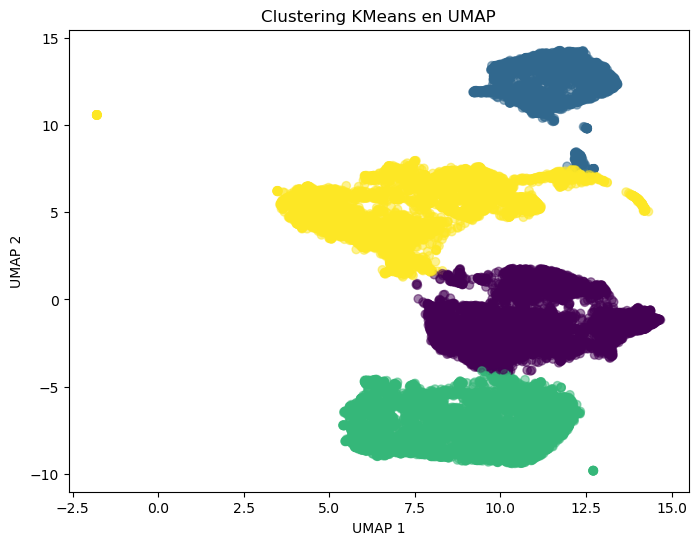

In [89]:
#Plotear el resultado de KMeans en UMAP.
kmeans_umap = KMeans(n_clusters=4, random_state=42)
clusters_umap = kmeans_umap.fit_predict(umap_result)
plt.figure(figsize=(8,6))
plt.scatter(umap_result[:,0], umap_result[:,1], c=clusters_umap, cmap='viridis', alpha=0.5)
plt.title('Clustering KMeans en UMAP')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

Podemos concluir que el caso de UMAP con k=4 es el mejor de los 3 casos analizados. Aunque el valor obtenido de silhouette no es excesivamente alto (0.55), es el mejor obtenido hasta ahora.

Como posibles siguientes pasos sería interesante evaluar el comportamiento de estos modelos utilizando más características en lugar de solamente 2.